# Detecting misclassifications on MNIST with safetycage

A classifier that is wrong and *knows* it is wrong is far more useful
than one that is wrong confidently. safetycage flags predictions a
model is likely to have got wrong, so they can be reviewed rather
than trusted.

This example wraps a PyTorch MLP trained on MNIST and puts the
**Maximum Softmax Probability (MSP)** cage around it.

**What you have to write to adopt safetycage** is two classes:

| File | Class | What it declares |
| --- | --- | --- |
| `mnist_datamodule.py` | `MNISTDataModule` | how data is loaded, transformed and split |
| `mlp_modelmodule.py` | `MLPModelModule` | how to get predictions, probabilities and activations out of the model |

Everything safetycage needs, it gets through those two objects.

## Setup

`fix_pythonpath_if_working_locally` points `import safetycage` at this
repository's `src/` if you´re working locally

In [1]:
import sys
sys.path.insert(0, '..')  # examples/, where utils.py lives

from utils import fix_pythonpath_if_working_locally
fix_pythonpath_if_working_locally()

%load_ext autoreload
%autoreload 2

## The data

`MNISTDataModule` downloads MNIST through torchvision and hands back
three splits, each an `(x, y)` tuple of numpy arrays. Validation is
carved out of the 60k training images; the 10k test images are
MNIST's own test split and are never used to fit anything.

torch.int64


/var/folders/71/r706jlxs11z389j47mwtlj5w0000gn/T/ipykernel_21142/2583628952.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(dataset.targets) # Get the labels as a numpy array


train x=(38400, 784) y=(38400,)
val   x=(7680, 784) y=(7680,)
test  x=(1920, 784) y=(1920,)


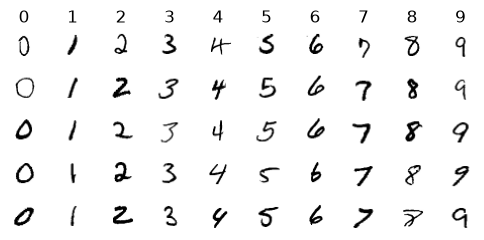

In [3]:
import torch
from torchvision import datasets
import numpy as np 
from sklearn.model_selection import train_test_split
from mnist_datamodule import MNISTDataModule

dataset = datasets.MNIST(root=str("./data"), train=True, download=True)
print(dataset.targets.dtype)
y = np.array(dataset.targets) # Get the labels as a numpy array

# Split the dataset into model and cage datasets
x_model, x_cage, y_model, y_cage = train_test_split(
    dataset.data, y, test_size=0.2, random_state=42, stratify=y
)

# Split the model dataset into training, validation, and testing sets
x_model_train, x_model_temp, y_model_train, y_model_temp = train_test_split(x_model, y_model, test_size=0.2, random_state=42, stratify=y_model)
x_model_val, x_model_test, y_model_val, y_model_test = train_test_split(x_model_temp, y_model_temp, test_size=0.2, random_state=42, stratify=y_model_temp)

DEVICE = torch.device("mps")

data_module_model = MNISTDataModule(
    x_train=x_model_train,
    y_train=y_model_train,
    x_val=x_model_val,
    y_val=y_model_val,
    x_test=x_model_test,
    y_test=y_model_test,
    device=DEVICE
    )

data_module_model.print_partition_summary()
data_module_model.plot_samples(n_samples_per_class=5)

## The model

A direct port of the Keras `Sequential` MLP: `784 → 256 → 128 → 10`,
ReLU between, softmax on the output. It was fitted by `train.py`, so
here we just load the checkpoint.

In [8]:
import os
import torch
from mlp import MLP

model = MLP()

CHECKPOINT = "./mlp_mnist.pt"
if os.path.exists(CHECKPOINT):
    print(f"Loading model from checkpoint: {CHECKPOINT}")
    model.load_state_dict(torch.load(CHECKPOINT))
model.to(DEVICE)

Loading model from checkpoint: ./mlp_mnist.pt


MLP(
  (mlp): Sequential(
    (dense_1): Linear(in_features=784, out_features=256, bias=True)
    (relu_1): ReLU()
    (dense_2): Linear(in_features=256, out_features=128, bias=True)
    (relu_2): ReLU()
    (dense_3): Linear(in_features=128, out_features=10, bias=True)
    (softmax): Softmax(dim=1)
  )
)

## Training the MLP

In [7]:
from torch.utils.data import DataLoader, TensorDataset
from torch import nn

def as_loader(split, batch_size, shuffle=False, device="cpu"):
    """Wrap an (x, y) numpy split as a DataLoader."""
    x, y = split

    return DataLoader(
        TensorDataset(torch.from_numpy(x).float().to(device), torch.from_numpy(y).long().to(device)),
        batch_size=batch_size,
        shuffle=shuffle,
    )

epochs = 10
batch_size = 64
learning_rate = 1e-3


train_loader = as_loader(data_module_model.data_train, batch_size, shuffle=True, device=DEVICE)
val_loader = as_loader(data_module_model.data_val, batch_size, device=DEVICE)
test_loader = as_loader(data_module_model.data_test, batch_size, device=DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()


@torch.no_grad()
def evaluate(model, loader, device="mps"):
    """Return (mean loss, accuracy) over a loader."""
    model.eval()
    loss_fn = nn.CrossEntropyLoss()

    total_loss, correct, seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)

        total_loss += loss_fn(logits, y).item() * len(y)
        correct += (logits.argmax(dim=1) == y).sum().item()
        seen += len(y)

    return total_loss / seen, correct / seen


for epoch in range(1, epochs + 1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

    val_loss, val_accuracy = evaluate(model, val_loader, device=DEVICE)
    print(f"epoch {epoch:2d}/{epochs}  val_loss {val_loss:.4f}  val_acc {val_accuracy:.4f}")


test_loss, test_accuracy = evaluate(model, test_loader, device=DEVICE)
print(f"test_loss {test_loss:.4f}  test_acc {test_accuracy:.4f}")

torch.save(model.state_dict(), CHECKPOINT)
print(f"saved {CHECKPOINT}")

epoch  1/10  val_loss 1.4705  val_acc 0.9910
epoch  2/10  val_loss 1.4692  val_acc 0.9919


KeyboardInterrupt: 

In [9]:
from mlp_modelmodule import MLPModelModule

model_module = MLPModelModule(
    selected_layers='dense_1',
    use_onehot_encoder=False,
    model=model,
    device=DEVICE
)

In [10]:
# Split the model dataset into training, validation, and testing sets
x_cage_train, x_cage_temp, y_cage_train, y_cage_temp = train_test_split(x_cage, y_cage, test_size=0.2, random_state=42)
x_cage_val, x_cage_test, y_cage_val, y_cage_test = train_test_split(x_cage_temp, y_cage_temp, test_size=0.2, random_state=42)

In [12]:
from mnist_datamodule import MNISTDataModule

data_module = MNISTDataModule(
    x_train=x_cage_train,
    y_train=y_cage_train,
    x_val=x_cage_val,
    y_val=y_cage_val,
    x_test=x_cage_test,
    y_test=y_cage_test,
    device=DEVICE
)

## How good is the model?

This matters for what follows: a cage can only be demonstrated on a
model that actually makes mistakes.

test samples       : 1920
accuracy           : 98.80%
misclassified      : 23


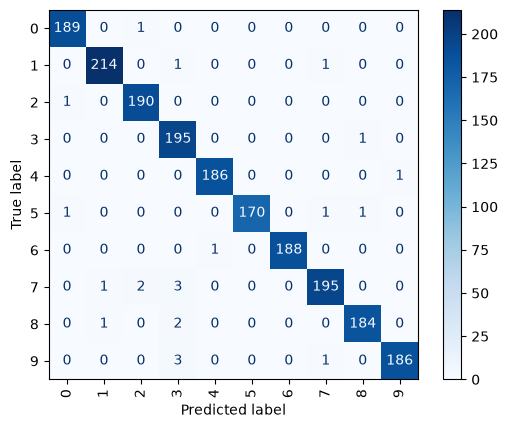

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

x_model_test, y_model_test = data_module_model.data_test
predictions_test = model_module._get_predictions(x_model_test)

incorrect_test = (predictions_test != y_model_test).astype(int)

print(f'test samples       : {len(x_model_test)}')
print(f'accuracy           : {(predictions_test == y_model_test).mean():.2%}')
print(f'misclassified      : {incorrect_test.sum()}')

cm = confusion_matrix(y_model_test, predictions_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data_module.classes.values())
cm_fig = disp.plot(cmap='Blues', xticks_rotation='vertical')

## Maximum Softmax Probability

MSP is the simplest safety cage: it treats the largest class
probability as a confidence score and flags anything below a
threshold. It needs no fitting, which is why `train_cage()` does
nothing here.

Hendrycks & Gimpel (2016), https://arxiv.org/abs/1610.02136

In [ ]:
from safetycage.methods.msp import MSP

safetycage = MSP(model_module=model_module, data_module=data_module)

# trains the cage with the train partition of the cage dataset partition
safetycage.train_cage()

In [15]:
# inference on validation partiion of the cage dataset
x_val, y_val = data_module_model.data_val
predictions_val = model_module._get_predictions(x_val)
incorrect_val = (predictions_val != y_val).astype(int)
statistics_val = safetycage.predict(x_val, predictions_val)

The gap between those two numbers is the entire premise of the
method. If it were absent, MSP would have nothing to work with.

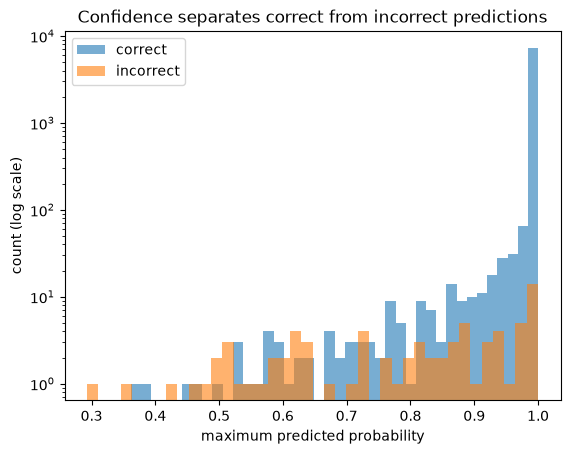

In [16]:
import matplotlib.pyplot as plt
plt.hist(statistics_val[incorrect_val == 0], bins=40, alpha=0.6, label='correct')
plt.hist(statistics_val[incorrect_val == 1], bins=40, alpha=0.6, label='incorrect')
plt.yscale('log')
plt.xlabel('maximum predicted probability')
plt.ylabel('count (log scale)')
plt.title('Confidence separates correct from incorrect predictions')
plt.legend()
plt.show()

## Choosing a threshold

`find_best_threshold` sweeps candidate thresholds and keeps the one
maximising the metric you pass. We use MCC, which reflects both precision and recall - and misclassifications are very much the minority
here.

Note this is the *method* on the cage object.
It takes no `leq` argument; it knows from `msp.leq` that low scores
mean 'flag this'.

In [17]:
from safetycage.utils.metrics import MCC
metric_fn = MCC

result_val = safetycage.find_best_threshold(
    y_true=incorrect_val,
    y_probs=statistics_val,
    metric_fn=metric_fn,
    search="log", 
)
threshold = result_val['threshold_opt']

print(f"optimal threshold : {result_val['threshold_opt']:.4f}")
print(f"{metric_fn.__name__} at threshold  : {float(result_val['metric_max']):.4f}")

optimal threshold : 0.8975
MCC at threshold  : 0.4627


## Applying it to held-out data

The threshold was chosen on validation data. Applying it to the test
split is the only honest estimate of how it will behave in use.

In [18]:
x_test, y_test = data_module.data_test

y_pred_test = model_module._get_predictions(x_test)
statistics_test = safetycage.predict(x_test, y_pred_test)
incorrect_test = (y_pred_test != y_test).astype(int)
result_test = safetycage.find_best_threshold(
    y_true=incorrect_test,
    y_probs=statistics_test,
    metric_fn=metric_fn,
    search="log"
)

flagged_test = safetycage.flag(statistics_test, threshold)

caught = int((flagged_test & (incorrect_test == 1)).sum())
total_errors = int(incorrect_test.sum())

print(f'test samples           : {len(x_test)}')
print(f'actually misclassified : {total_errors}')
print(f'flagged by the cage    : {int(flagged_test.sum())}')
print(f'errors caught          : {caught} of {total_errors} ({caught / total_errors:.0%})')

test samples           : 480
actually misclassified : 6
flagged by the cage    : 10
errors caught          : 6 of 6 (100%)


In [19]:
x_train, y_train = data_module.data_train
y_pred_train = model_module._get_predictions(x_train)
statistics_train = safetycage.predict(x_train, y_pred_train)
incorrect_train = (y_pred_train != y_train).astype(int)

result_train = safetycage.find_best_threshold(
    y_true=incorrect_train,
    y_probs=statistics_train,
    metric_fn=metric_fn,
    search="log"
)

flagged_train = safetycage.flag(statistics_train, result_train['threshold_opt'])

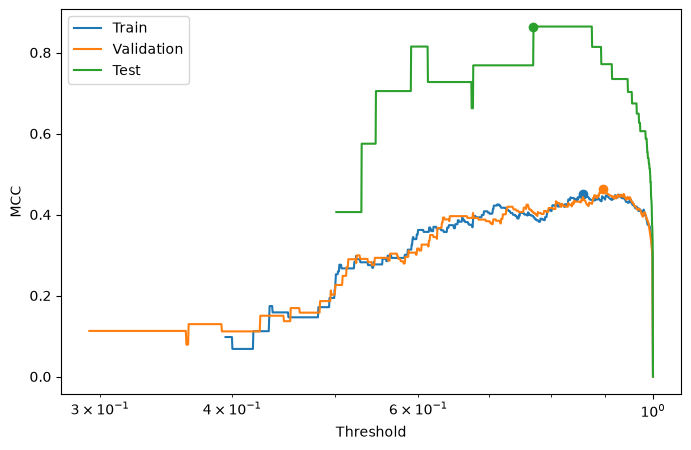

In [20]:
import matplotlib.pyplot as plt
from safetycage.utils.visualise import plot_metric_vs_threshold

fig, ax = plt.subplots(figsize=(8, 5))
plot_metric_vs_threshold(result_train['thresholds'], result_train['metrics'], ax=ax, label='Train')
plot_metric_vs_threshold(result_val['thresholds'], result_val['metrics'], ax=ax, label='Validation')
plot_metric_vs_threshold(result_test['thresholds'], result_test['metrics'], ax=ax, label='Test')
plt.xlabel('Threshold')
plt.ylabel(metric_fn.__name__)
plt.xscale('log')
ax.legend()
plt.show()

In [21]:
auroc = safetycage.auroc(y_true=incorrect_test, y_pred=statistics_test)
roc = safetycage.roc_curve(y_true=incorrect_test, y_pred=statistics_test)

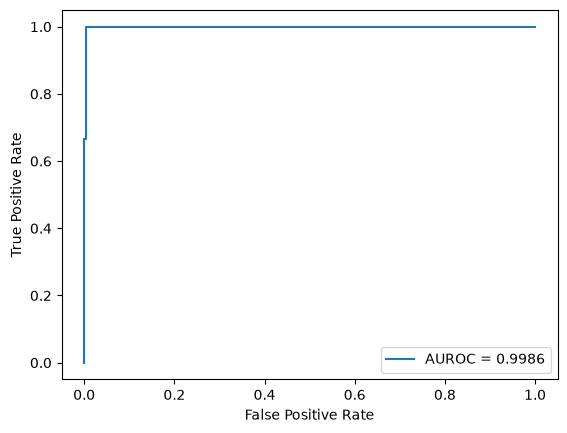

In [22]:
plt.plot(roc['fpr'], roc['tpr'], label=f'AUROC = {auroc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

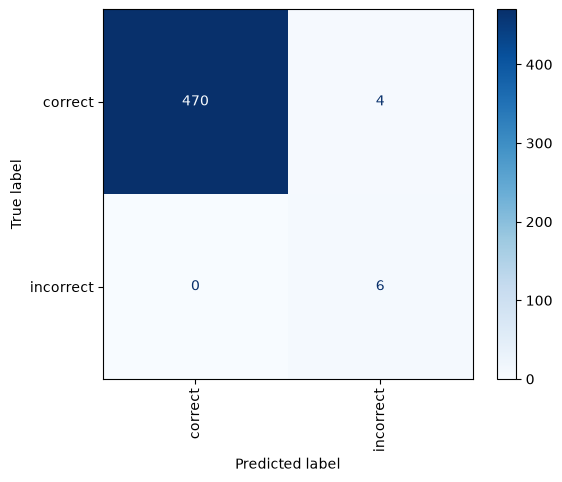

In [23]:
cm = confusion_matrix(y_true=incorrect_test, y_pred=flagged_test, normalize=None)
confusion_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['correct', 'incorrect'])
confusion_disp.plot(cmap='Blues', xticks_rotation='vertical')


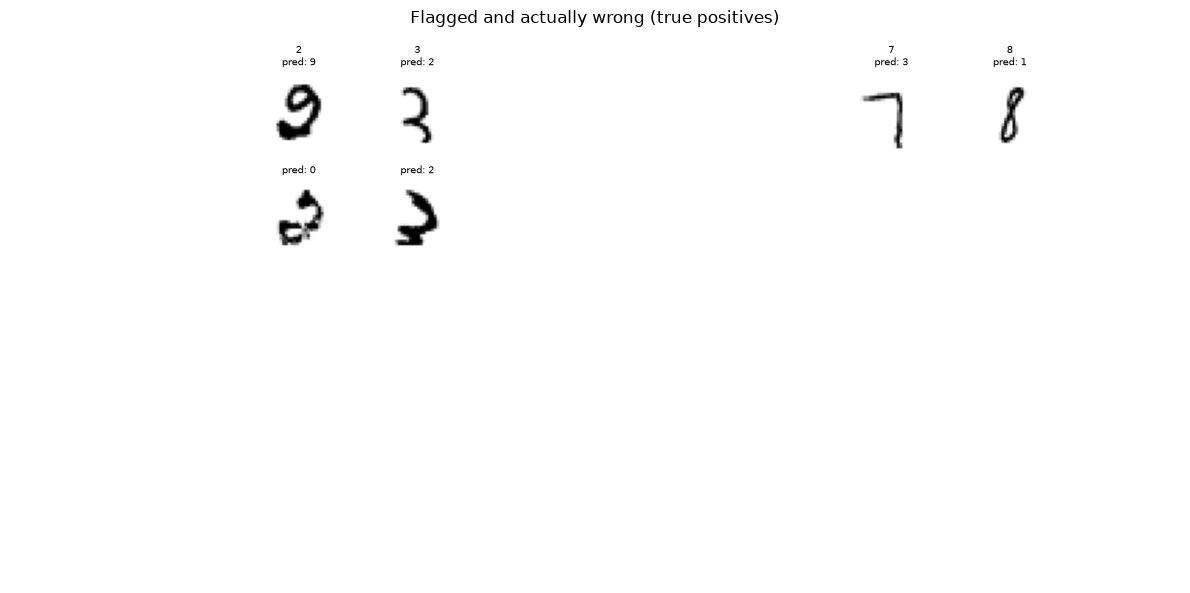

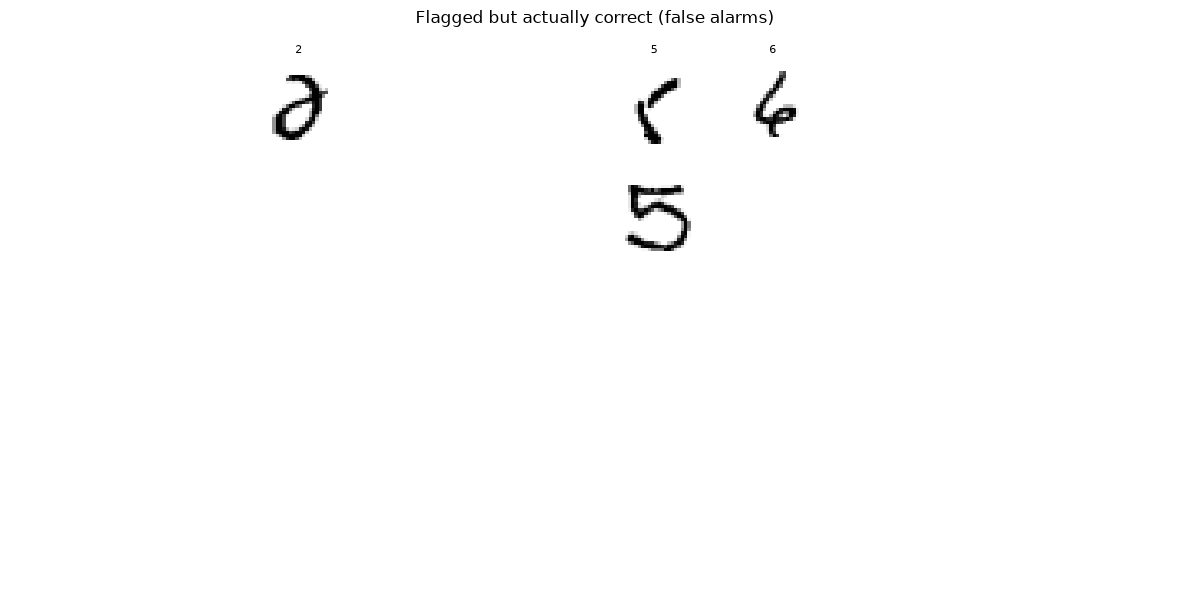

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mnist_datamodule import MNIST_MEAN, MNIST_STD

N = 5  # rows per plot

def to_displayable(img):
    """Flat (784,) normalized float -> (28, 28) grayscale in [0, 1]."""
    if data_module.normalize:
        img = img * MNIST_STD + MNIST_MEAN
    return np.clip(img.reshape(28, 28), 0, 1)


def plot_flagged_grid(mask, title, n_rows=N, show_prediction=False):
    fig, axes = plt.subplots(
        n_rows, data_module.num_classes,
        figsize=(data_module.num_classes * 1.2, n_rows * 1.2),
        squeeze=True,
    )

    for class_id, class_name in data_module.classes.items():
        class_idx = np.where((y_test == class_id) & mask)[0][:n_rows]

        for row in range(n_rows):
            ax = axes[row, class_id]
            if row < len(class_idx):
                idx = class_idx[row]
                ax.imshow(to_displayable(x_test[idx]), cmap="gray_r")

                if show_prediction:
                    pred_label = data_module.classes[int(y_pred_test[idx])]
                    label = f"{class_name}\npred: {pred_label}" if row == 0 else f"pred: {pred_label}"
                    ax.set_title(label, fontsize=7)
                elif row == 0:
                    ax.set_title(class_name, fontsize=8)
            ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
actually_wrong = flagged_test & (incorrect_test == 1)
false_alarms = flagged_test & (incorrect_test == 0)

plot_flagged_grid(actually_wrong, "Flagged and actually wrong (true positives)", show_prediction=True)
plot_flagged_grid(false_alarms, "Flagged but actually correct (false alarms)")

## Scenario 1: abstain on what the cage flags

The simplest way to use the cage: don't act on any prediction it flags at
all, and only trust the ones it lets through. That raises the reliability
of what you do act on, but costs coverage — fewer predictions you're
willing to use.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

kept = ~flagged_test
missed_mask = kept & (incorrect_test == 1)
caught_mask = flagged_test & (incorrect_test == 1)

def classifier_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

baseline_metrics = classifier_metrics(y_test, y_pred_test)
kept_metrics = classifier_metrics(y_test[kept], y_pred_test[kept])

print(f'{"metric":<20}{"baseline":>15}{"cage-kept":>15}{"change":>15}')
for name in baseline_metrics:
    print(f'{name:<20}{baseline_metrics[name]:>15.4f}{kept_metrics[name]:>15.4f}{kept_metrics[name] - baseline_metrics[name]:>+15.4f}')

print()
print(f'sent for review         : {int(flagged_test.sum())} of {len(x_test)}')
print(f'errors missed           : {int(missed_mask.sum())} of {total_errors}')
print(f'errors caught           : {int(caught_mask.sum())} of {total_errors}')
print(f'coverage                : {kept.mean():.2%} ({int(kept.sum())} of {len(x_test)})')

metric                     baseline      cage-kept         change
accuracy                     0.9875         1.0000        +0.0125
precision (macro)            0.9875         1.0000        +0.0125
recall (macro)               0.9871         1.0000        +0.0129
f1 (macro)                   0.9872         1.0000        +0.0128
MCC                          0.9861         1.0000        +0.0139

sent for review         : 10 of 480
errors missed           : 0 of 6
errors caught           : 6 of 6
coverage                : 97.92% (470 of 480)


## Scenario 2: review everything flagged, correct what's wrong

A different deployment: instead of abstaining, send every flagged sample
for review. A reviewer fixes the ones that really were misclassified and
leaves the false alarms as they were (already correct, just cost some
review time). Predictions the cage never flagged are left untouched —
including the errors it missed.

In [27]:
caught_mask = flagged_test & (incorrect_test == 1)
missed_mask = (~flagged_test) & (incorrect_test == 1)

corrected_test = y_pred_test.copy()
corrected_test[caught_mask] = y_test[caught_mask]

corrected_metrics = classifier_metrics(y_test, corrected_test)

print(f'{"metric":<20}{"baseline":>15}{"with review":>15}{"change":>15}')
for name in baseline_metrics:
    print(f'{name:<20}{baseline_metrics[name]:>15.4f}{corrected_metrics[name]:>15.4f}{corrected_metrics[name] - baseline_metrics[name]:>+15.4f}')

print()
print(f'sent for review         : {int(flagged_test.sum())} of {len(x_test)}')
print(f'errors missed           : {int(missed_mask.sum())} of {total_errors}')
print(f'errors caught           : {int(caught_mask.sum())} of {total_errors}')

metric                     baseline    with review         change
accuracy                     0.9875         1.0000        +0.0125
precision (macro)            0.9875         1.0000        +0.0125
recall (macro)               0.9871         1.0000        +0.0129
f1 (macro)                   0.9872         1.0000        +0.0128
MCC                          0.9861         1.0000        +0.0139

sent for review         : 10 of 480
errors missed           : 0 of 6
errors caught           : 6 of 6
